
---

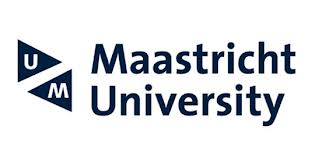

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


By Jan Scholtes


---

Version 2026-2027

---

Welcome to the tutorial on Fine-Tuning Large Language Models (LLMs). In this notebook you will first learn about methods to create training datasets with minimal human effort, and then explore how to fine-tune pre-trained Transformer models for specific NLP tasks.

For this notebook we would need our GPU accelerator.

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** the challenges of obtaining labeled training data for NLP and why it matters.
- **Apply** different methods (distant supervision, active learning, data augmentation) to create training datasets with minimal human involvement.
- **Explain** why human involvement remains essential for high-quality training data.
- **Fine-tune** a pre-trained BERT model for text classification tasks.
- **Fine-tune** GPT-2 for domain-specific text generation.
- **Understand** parameter-efficient fine-tuning techniques such as Adapters and LoRA.
- **Compare** distillation, quantization, and pruning as methods to make LLMs more efficient.

# Part 1: Creating Training Datasets for NLP

Deep learning models are very data hungry. Other machine learning methods require less data, but getting labeled data -- especially for domain-specific applications -- is a slow and expensive process. Human bias only adds to the problem.

Over time, many different methods have been developed to create more labeled data for machine learning with minimal human involvement. In this section we discuss the most important ones.

There is always a need for (human) annotated or ranked data sets, definitely for encoder and encoder-decoder models, but also for decoder-only models. The key challenge is: **how do we get more labeled data without breaking the bank?**

## Distant Supervision

**Distant supervision** is a method to automatically generate labeled training data by exploiting existing knowledge bases, databases, or heuristic rules. Instead of manually annotating each example, you write *labeling functions* that programmatically assign labels based on patterns, dictionaries, or external data sources.

### How It Works

1. **Define labeling functions**: Each function encodes a heuristic or rule. For example, for sentiment analysis:
   - If the text contains words like "excellent", "amazing", "love" → label as POSITIVE
   - If the text contains words like "terrible", "awful", "hate" → label as NEGATIVE
   - If the text matches a known product complaint pattern → label as NEGATIVE

2. **Apply labeling functions** to unlabeled data: Each function votes on a label for each example. Functions may abstain, agree, or conflict.

3. **Combine and denoise**: Use a label model to learn the accuracy and correlation of each labeling function and produce a single probabilistic label per example.

4. **Train a downstream model**: Use the probabilistic labels to train a standard ML classifier.

### Advantages
- Can label thousands of examples in hours instead of weeks
- Labeling functions are interpretable and debuggable
- Easy to iterate: modify rules and re-label

### Limitations
- Labeling functions may have low coverage or accuracy
- Conflicting functions need careful resolution
- Still requires domain expertise to write good labeling functions

**Note:** The Snorkel platform, originally developed at Stanford, was a popular tool for distant supervision. However, Snorkel AI has pivoted to a commercial enterprise platform and the open-source version is no longer actively maintained. The concepts and techniques remain valuable and are implemented in modern alternatives such as **Wrench**, **Flyingsquid**, and custom implementations using simple Python code.

In [ ]:
# Example: Simple distant supervision with labeling functions
# No external library needed - just Python!
import numpy as np
from collections import Counter

# Simulated unlabeled data
texts = [
    "This product is absolutely amazing and works perfectly!",
    "Terrible quality, broke after one day of use.",
    "The package arrived on time, nothing special.",
    "I love this! Best purchase I've ever made.",
    "Awful customer service, will never buy again.",
    "It's okay, does what it's supposed to do.",
    "Fantastic design and great build quality!",
    "Worst experience ever. Complete waste of money.",
    "Decent product for the price point.",
    "Highly recommend this to everyone!"
]

# Define labeling functions (return 1=POS, 0=NEG, -1=ABSTAIN)
def lf_positive_words(text):
    pos_words = ["amazing", "love", "fantastic", "great", "best", "excellent", "recommend", "perfect"]
    if any(w in text.lower() for w in pos_words):
        return 1
    return -1

def lf_negative_words(text):
    neg_words = ["terrible", "awful", "worst", "broke", "waste", "never buy", "horrible"]
    if any(w in text.lower() for w in neg_words):
        return 0
    return -1

def lf_exclamation_positive(text):
    if text.endswith("!") and any(w in text.lower() for w in ["love", "best", "recommend"]):
        return 1
    return -1

# Apply labeling functions
labeling_functions = [lf_positive_words, lf_negative_words, lf_exclamation_positive]
label_matrix = np.array([[lf(t) for lf in labeling_functions] for t in texts])

# Simple majority voting (ignoring abstains)
def majority_vote(row):
    votes = [v for v in row if v != -1]
    if not votes:
        return -1  # no label
    return Counter(votes).most_common(1)[0][0]

labels = [majority_vote(row) for row in label_matrix]

print("Distant Supervision Results:")
print(f"{'Text':<60} {'Label':>5}")
print("-" * 67)
for text, label in zip(texts, labels):
    label_str = {1: "POS", 0: "NEG", -1: "UNK"}[label]
    print(f"{text[:58]:<60} {label_str:>5}")

labeled = sum(1 for l in labels if l != -1)
print(f"\nLabeled {labeled}/{len(texts)} examples automatically")

## Active Learning

**Active learning** is a strategy where the machine learning model itself selects the most informative examples for a human to label. Instead of randomly labeling data, the model identifies examples where it is most uncertain, and asks a human annotator to label only those.

### The Active Learning Loop

1. **Train** an initial model on a small labeled seed set
2. **Apply** the model to a pool of unlabeled data
3. **Select** the examples where the model is most uncertain (e.g., prediction probability closest to 0.5 for binary classification)
4. **Ask a human** to label those selected examples
5. **Add** the newly labeled examples to the training set
6. **Repeat** until performance is satisfactory or the labeling budget is exhausted

### Selection Strategies

| Strategy | Description |
|---|---|
| **Uncertainty sampling** | Select examples with highest prediction uncertainty |
| **Query-by-committee** | Multiple models vote; select examples with most disagreement |
| **Expected model change** | Select examples that would change the model the most |
| **Diversity sampling** | Select examples that are most diverse/representative |

### Why It Works

Active learning can achieve the same model performance with **40-80% fewer labeled examples** compared to random sampling, because the human effort is focused on the most informative cases.

### When to Use Active Learning

- You have a large pool of unlabeled data
- Labeling is expensive (requires domain experts)
- You need to maximize model performance under a fixed labeling budget

In [ ]:
# Example: Active learning with uncertainty sampling
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Full dataset (imagine only a few are labeled initially)
all_texts = [
    "This movie was absolutely wonderful", "Terrible acting throughout",
    "A masterpiece of modern cinema", "Boring and predictable plot",
    "Loved every minute of it", "Complete waste of time",
    "Beautiful cinematography", "Awful dialogue and pacing",
    "Highly entertaining film", "The worst movie this year",
    "Great performances by the cast", "Disappointing and overrated",
    "A delightful experience", "Painful to watch",
    "Outstanding storytelling", "Dull and uninspired"
]
all_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# Start with only 4 labeled examples (seed set)
labeled_idx = [0, 1, 2, 3]
unlabeled_idx = list(range(4, len(all_texts)))

vectorizer = TfidfVectorizer()
X_all = vectorizer.fit_transform(all_texts)

# Active learning loop
for iteration in range(3):
    # Train on current labeled set
    X_train = X_all[labeled_idx]
    y_train = [all_labels[i] for i in labeled_idx]
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)

    # Predict probabilities on unlabeled pool
    X_pool = X_all[unlabeled_idx]
    probs = model.predict_proba(X_pool)

    # Uncertainty sampling: select the 2 most uncertain examples
    uncertainty = 1 - np.max(probs, axis=1)
    top_uncertain = np.argsort(uncertainty)[-2:]

    # "Label" these (simulate human annotation)
    selected = [unlabeled_idx[i] for i in top_uncertain]
    print(f"Iteration {iteration + 1}: Model selected for labeling:")
    for idx in selected:
        print(f"  '{all_texts[idx]}' (true label: {'POS' if all_labels[idx] else 'NEG'})")

    labeled_idx.extend(selected)
    unlabeled_idx = [i for i in unlabeled_idx if i not in selected]

# Final model accuracy
X_test = X_all[unlabeled_idx] if unlabeled_idx else X_all
y_test = [all_labels[i] for i in (unlabeled_idx if unlabeled_idx else range(len(all_labels)))]
accuracy = model.score(X_test, y_test)
print(f"\nFinal model accuracy with {len(labeled_idx)} labeled examples: {accuracy:.1%}")
print(f"(Started with 4, added {len(labeled_idx)-4} via active learning)")

## Data Augmentation

**Data augmentation** creates new training examples by applying transformations to existing labeled data. The key insight is that small modifications to text usually preserve the label.

### Common NLP Data Augmentation Techniques

| Technique | Description | Example |
|---|---|---|
| **Synonym replacement** | Replace words with synonyms | "The movie was *great*" → "The movie was *excellent*" |
| **Random insertion** | Insert a random synonym of a random word | "I loved the film" → "I really loved the film" |
| **Random swap** | Swap the position of two random words | "The cat sat on the mat" → "The mat sat on the cat" |
| **Random deletion** | Randomly remove words with probability p | "I really loved this movie" → "I loved this movie" |
| **Back-translation** | Translate to another language and back | English → French → English |
| **Contextual augmentation** | Use a language model (e.g. BERT) to replace words with contextually similar alternatives | MLM-based substitution |

### EDA: Easy Data Augmentation

EDA (Wei & Zou, 2019) is a simple yet effective technique that combines synonym replacement, random insertion, random swap, and random deletion. It was shown to improve text classification performance, especially on small datasets.

### LLM-based Augmentation

Modern approaches use large language models to generate paraphrases or new examples:
- **Prompt-based generation**: Ask an LLM to generate examples for a class
- **Self-training**: Use the model's own predictions on unlabeled data as pseudo-labels

In [ ]:
# Example: Simple data augmentation using EDA techniques
import random
import re

def synonym_replace(text, n=1):
    """Replace n random words with simple synonyms."""
    # Small synonym dictionary for demonstration
    synonyms = {
        "good": ["great", "excellent", "fine", "wonderful"],
        "bad": ["terrible", "awful", "poor", "dreadful"],
        "happy": ["glad", "pleased", "delighted", "joyful"],
        "sad": ["unhappy", "sorrowful", "gloomy", "melancholy"],
        "big": ["large", "huge", "enormous", "massive"],
        "small": ["tiny", "little", "miniature", "compact"],
        "fast": ["quick", "rapid", "swift", "speedy"],
        "movie": ["film", "picture", "motion picture"],
        "love": ["adore", "enjoy", "cherish"],
        "beautiful": ["stunning", "gorgeous", "lovely"],
    }
    words = text.split()
    replaced = 0
    for i, word in enumerate(words):
        clean_word = word.lower().strip(".,!?")
        if clean_word in synonyms and replaced < n:
            new_word = random.choice(synonyms[clean_word])
            words[i] = new_word
            replaced += 1
    return " ".join(words)

def random_deletion(text, p=0.1):
    """Randomly delete words with probability p."""
    words = text.split()
    if len(words) <= 1:
        return text
    remaining = [w for w in words if random.random() > p]
    return " ".join(remaining) if remaining else random.choice(words)

def random_swap(text, n=1):
    """Randomly swap n pairs of words."""
    words = text.split()
    for _ in range(n):
        if len(words) >= 2:
            i, j = random.sample(range(len(words)), 2)
            words[i], words[j] = words[j], words[i]
    return " ".join(words)

# Original examples
originals = [
    ("This movie was good and I was happy", 1),
    ("The film had bad acting and was sad", 0),
    ("A beautiful and fast paced love story", 1),
]

print("Data Augmentation Examples:")
print("=" * 70)
random.seed(42)
for text, label in originals:
    label_str = "POS" if label else "NEG"
    print(f"\nOriginal [{label_str}]: {text}")
    print(f"  Synonym:   {synonym_replace(text, n=2)}")
    print(f"  Deletion:  {random_deletion(text, p=0.2)}")
    print(f"  Swap:      {random_swap(text, n=1)}")

## Other Methods to Create Training Data

### Self-Training (Pseudo-Labeling)
Train a model on a small labeled set, use it to predict labels for unlabeled data, then retrain on the combined set. Works best when the initial model is already reasonably accurate.

### Few-Shot Annotation with LLMs
Use large language models (GPT-4, Claude, etc.) to annotate data with few-shot prompts. The LLM acts as an automatic annotator given a few examples. This is increasingly popular but requires careful validation.

### Crowdsourcing
Platforms like Amazon Mechanical Turk, Prolific, or Label Studio allow distributing labeling tasks to many annotators. Multiple annotations per example help reduce individual bias.

### Transfer Learning from Related Datasets
Pre-train or fine-tune on a related dataset from a different domain, then adapt to your target domain with fewer labels.

## The Role of Human Involvement

While all these methods reduce the need for human annotation, **human involvement remains essential** for several reasons:

1. **Quality control**: Automated labels are noisy. Humans are needed to validate and correct a sample of the generated labels.

2. **Edge cases**: Automated methods struggle with ambiguous, nuanced, or context-dependent examples that require human judgment.

3. **Adding interesting information**: Humans contribute domain knowledge, cultural context, and common-sense reasoning that no automated method can fully capture. For example, understanding irony, sarcasm, or domain-specific jargon requires human expertise.

4. **Evaluation**: The final test set must always be human-annotated to ensure reliable performance measurement.

5. **Ethical considerations**: Humans must oversee the labeling process to prevent systematic biases from being encoded into the training data.

**Best practice**: Use automated methods to generate a large initial dataset, then have humans review and correct a representative sample. This hybrid approach balances scale with quality.

# Part 2: Fine-Tuning Large Language Models

Fine-tuning is the process of taking a **pre-trained** model and adapting it to a specific downstream task using labeled data. The pre-trained model has already learned general language representations from large corpora; fine-tuning adjusts these representations for your particular use case.

| Aspect | Pre-Training | Fine-Tuning |
|---|---|---|
| **Starting point** | Random weights | Pre-trained weights |
| **Data** | Large unlabeled corpus | Smaller task-specific labeled data |
| **Goal** | Learn general language understanding | Adapt to a specific task |
| **Cost** | Very expensive (days/weeks on many GPUs) | Relatively cheap (hours on 1 GPU) |
| **Examples** | BERT on BookCorpus + Wikipedia | BERT for sentiment analysis |

## Fine-Tuning BERT for Text Classification

BERT (Bidirectional Encoder Representations from Transformers) can be fine-tuned for various NLP tasks by adding a task-specific head on top of the pre-trained model:

- **Single sentence classification** (e.g., sentiment analysis): Use the `[CLS]` token embedding → classification layer
- **Sentence pair classification** (e.g., NLI, similarity): Two sequences with `[SEP]` → `[CLS]` embedding → classifier
- **Token classification** (e.g., NER, POS tagging): Each token embedding → per-token classifier
- **Question answering**: Predict start and end token positions in a passage

### What Happens During Fine-Tuning?

1. All pre-trained BERT weights are loaded
2. A small classification head (linear layer) is added on top
3. The entire model is trained end-to-end on the task-specific data
4. The learning rate is kept small (typically 2e-5 to 5e-5) to avoid "catastrophic forgetting"
5. Training usually takes only 2-4 epochs

BERT-base has approximately **110 million** trainable parameters. During fine-tuning, all of these are updated (embeddings, attention weights $W_Q$, $W_K$, $W_V$, feed-forward layers, plus the new classification head).

In [ ]:
# Fine-tuning BERT for sentiment classification (SST-2)
import importlib, subprocess, sys
if importlib.util.find_spec("transformers") is None or importlib.util.find_spec("datasets") is None or importlib.util.find_spec("accelerate") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 'transformers', 'datasets', 'accelerate'])

import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import load_dataset
import numpy as np

# Load a small subset of SST-2 for demonstration
dataset = load_dataset("glue", "sst2")

# Use a small subset for quick training in Colab
train_dataset = dataset["train"].shuffle(seed=42).select(range(1000))
val_dataset = dataset["validation"].shuffle(seed=42).select(range(200))

# Load pre-trained BERT tokenizer and model
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2
)

# Tokenize the datasets
def tokenize_function(examples):
    return tokenizer(
        examples["sentence"], padding="max_length", truncation=True, max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./bert_sst2_results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none",  # disable wandb etc.
)

# Define metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

# Create Trainer and train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# Train the model
trainer.train()

# Evaluate
results = trainer.evaluate()
print(f"\nFine-tuned BERT accuracy on SST-2 validation: {results['eval_accuracy']:.1%}")

In [ ]:
# Test the fine-tuned model on new sentences
from transformers import pipeline

# Create a pipeline with our fine-tuned model
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if __import__('torch').cuda.is_available() else -1
)

test_sentences = [
    "This movie is a masterpiece of storytelling.",
    "I was bored throughout the entire film.",
    "The acting was decent but the plot was confusing.",
    "Absolutely loved it! One of the best films this year.",
    "A complete disaster from start to finish."
]

print("Fine-tuned BERT Predictions:")
print("-" * 60)
for sent in test_sentences:
    result = classifier(sent)[0]
    label = "POSITIVE" if result["label"] == "LABEL_1" else "NEGATIVE"
    print(f"  {label} ({result['score']:.3f}): {sent}")

## Fine-Tuning GPT-2 for Text Generation

GPT-2 is a decoder-only autoregressive model trained to predict the next token. Fine-tuning GPT-2 adapts it to generate text in a specific style or domain.

### How GPT-2 Training Works

1. The corpus is broken into sequences of uniform size (e.g., 512 or 1024 tokens)
2. For each position in the sequence, the model predicts the next token
3. The loss is the cross-entropy between predicted and actual next tokens
4. Backpropagation updates all model weights

### Fine-Tuning vs Pre-Training

- **Pre-training from scratch**: Start with random weights, train on a large general corpus. Very expensive (can exceed EUR 10k for GPT-2 scale).
- **Fine-tuning**: Start with pre-trained weights, train on a smaller domain-specific corpus. Much cheaper and faster.

Examples of fine-tuned GPT-2 models:
- **PubMedGPT 2.7B**: Fine-tuned exclusively on biomedical abstracts (Stanford HAI)
- **CodeGPT**: Fine-tuned on source code for code generation
- **DialogGPT**: Fine-tuned on Reddit conversations for dialogue

In [ ]:
# Fine-tuning GPT-2 on a small custom dataset
import importlib, subprocess, sys
if importlib.util.find_spec("transformers") is None or importlib.util.find_spec("datasets") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 'transformers', 'datasets'])

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from datasets import Dataset

# Our "domain" corpus: short science fiction snippets
sci_fi_texts = [
    "The spaceship emerged from hyperspace near the binary star system.",
    "Captain Zara activated the neural interface and connected to the ship's AI.",
    "The alien artifact pulsed with an otherworldly blue light.",
    "Quantum tunneling allowed instantaneous communication across galaxies.",
    "The terraforming drones had been working on Mars for three centuries.",
    "In the year 3042, humanity had colonized seventeen star systems.",
    "The android looked indistinguishable from a human being.",
    "Warp drive technology revolutionized interstellar travel.",
    "The space station orbited silently above the gas giant.",
    "Cryogenic sleep made the long journey between stars bearable.",
    "The force field shimmered as the meteorites bounced off its surface.",
    "First contact with the Centauri species changed everything we knew.",
    "The galactic council convened to discuss the fate of the outer colonies.",
    "Neural implants gave humans direct access to the vast digital networks.",
    "The generation ship had been traveling for five hundred years.",
]

# Load GPT-2 tokenizer and model
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name)

# Tokenize
dataset = Dataset.from_dict({"text": sci_fi_texts})

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128, padding="max_length")

tokenized_dataset = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

# Data collator for causal LM (shifts labels automatically)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Training arguments (very light for demo)
training_args = TrainingArguments(
    output_dir="./gpt2_scifi",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
)

trainer.train()
print("GPT-2 fine-tuning complete!")

In [ ]:
# Generate text with the fine-tuned model
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if __import__('torch').cuda.is_available() else -1
)

prompts = [
    "The spaceship",
    "In the year 3042",
    "The alien artifact",
]

print("Fine-tuned GPT-2 Generations:")
print("=" * 60)
for prompt in prompts:
    output = generator(
        prompt,
        max_new_tokens=40,
        num_return_sequences=1,
        temperature=0.8,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    print(f"\nPrompt: '{prompt}'")
    print(f"Generated: {output[0]['generated_text']}")

## Parameter-Efficient Fine-Tuning: Adapters

Full fine-tuning updates all model parameters, which is expensive and requires storing a complete copy of the model for each task. **Adapters** offer a more efficient alternative.

### What are Adapters?

Adapters are small trainable modules inserted into the layers of a pre-trained Transformer model. The original model weights are **frozen**, and only the adapter weights are trained.

- Introduced by Houlsby et al. (2019): "Parameter-Efficient Transfer Learning for NLP"
- Each adapter consists of a **down-projection** (compress), a **non-linearity**, and an **up-projection** (expand)
- Typically adds only **2-4%** extra parameters per task

### Benefits

| Aspect | Full Fine-Tuning | Adapter Fine-Tuning |
|---|---|---|
| **Parameters trained** | All (~110M for BERT-base) | Only adapter layers (~2-4M) |
| **Storage per task** | Full model copy | Only adapter weights |
| **Multi-task** | Separate models | Shared backbone + task adapters |
| **Training speed** | Slower | Faster |
| **Performance** | Baseline | Near-baseline (within 1-2%) |

### How They Work

```
Input → Frozen Layer → Adapter(Down → ReLU → Up) + Residual → Output
```

The adapter has a bottleneck architecture: it projects the hidden state down to a smaller dimension, applies a non-linearity, and projects back up. The residual connection ensures that when adapters are randomly initialized, the model behaves like the original.

## Low-Rank Adaptation (LoRA)

**LoRA** (Hu et al., 2021) is another parameter-efficient fine-tuning method that has become extremely popular, especially for large models.

### The Key Idea

Instead of updating the full weight matrix $W$ during fine-tuning, LoRA decomposes the weight update into two low-rank matrices:

$$W' = W + \Delta W = W + BA$$

Where:
- $W \in \mathbb{R}^{d \times d}$ is the original (frozen) weight matrix
- $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times d}$ are the trainable low-rank matrices
- $r \ll d$ is the rank (typically 4, 8, or 16)

### Why It Works

The weight updates during fine-tuning tend to have a **low intrinsic rank** -- meaning the changes can be well-approximated by low-rank matrices. LoRA exploits this by directly parameterizing the update as low-rank.

### QLoRA: Quantized LoRA

**QLoRA** (Dettmers et al., 2023) combines LoRA with quantization:
1. The base model is loaded in 4-bit quantized format (reducing memory by ~4x)
2. LoRA adapters are added in full precision
3. Only the LoRA adapters are trained

This enables fine-tuning a 65B parameter model on a single 48GB GPU!

### LoRA vs Adapters

| Aspect | Adapters | LoRA |
|---|---|---|
| **Architecture** | New layers inserted | Modifies existing weight matrices |
| **Inference overhead** | Slight (extra computation) | None (weights can be merged) |
| **Flexibility** | Per-layer control | Per-matrix control |
| **Popularity** | Earlier, well-established | Current standard for LLM fine-tuning |

## Making LLMs More Efficient: Distillation, Quantization, and Pruning

Large models are expensive to run. Several techniques exist to make them smaller and faster while preserving most of their performance.

### Knowledge Distillation

A large **teacher** model trains a smaller **student** model:
1. The teacher generates "soft labels" (probability distributions) for training data
2. The student learns to mimic these soft distributions, not just the hard labels
3. The total loss combines student loss with distillation loss:

$$\mathcal{L}_{total} = \alpha \cdot \mathcal{L}_{student} + (1 - \alpha) \cdot \mathcal{L}_{distill}$$

**Example**: DistilBERT retains **97% of BERT's performance** while being **40% smaller** and **60% faster**.

### Quantization

Reduce the numerical precision of model weights:
- **FP32 → FP16**: 2x memory reduction, minimal accuracy loss
- **FP32 → INT8**: 4x memory reduction, small accuracy loss
- **FP32 → INT4**: 8x memory reduction, moderate accuracy loss

Types:
- **Post-Training Quantization (PTQ)**: Quantize after training
- **Quantization-Aware Training (QAT)**: Train with quantization in mind

**Extreme example**: BitNet b1.58 uses coefficients in $\{-1, 0, 1\}$ and achieves similar performance to the base LLaMA model with **71x less energy consumption**!

### Pruning

Remove unnecessary weights or neurons:
- **Weight pruning**: Set individual weights to zero (unstructured sparsity)
- **Neuron pruning**: Remove entire neurons or attention heads (structured pruning)
- Leads to more efficient matrix calculations in terms of both memory and computation

## Take Away

### Key Concepts

1. **Training data is the bottleneck**: Creating labeled datasets is expensive and time-consuming. Methods like distant supervision, active learning, and data augmentation help reduce the human effort but cannot fully replace it.

2. **Human involvement remains essential**: Automated labeling methods produce noisy labels. Humans are needed for quality control, edge cases, domain expertise, and evaluation. The best approach is a hybrid: automated methods for scale, humans for quality.

3. **Fine-tuning adapts pre-trained models**: Instead of training from scratch, fine-tuning starts from pre-trained weights and adapts them to a specific task. This is much cheaper and requires far less data.

4. **Parameter-efficient methods save resources**: Adapters, LoRA, and QLoRA allow fine-tuning with a fraction of the parameters, making it possible to customize even very large models on modest hardware.

5. **Efficiency techniques enable deployment**: Distillation, quantization, and pruning make large models practical for production use by reducing size, speed, and energy consumption.

### Method Summary

| Method | Purpose | Key Benefit |
|---|---|---|
| **Distant supervision** | Label data automatically | Scale: thousands of labels in hours |
| **Active learning** | Smart human labeling | 40-80% fewer labels needed |
| **Data augmentation** | More training examples | Better generalization |
| **Full fine-tuning** | Adapt pre-trained model | Best task performance |
| **Adapters / LoRA** | Efficient fine-tuning | 2-4% extra parameters |
| **Distillation** | Compress model | 40% smaller, 97% performance |
| **Quantization** | Reduce precision | 2-8x memory reduction |

# Exercises

## Exercise A1: Creating an Annotated Dataset with Distant Supervision (15 points)

We provide a skeleton that loads the AG News dataset and includes three labeling functions for topic classification (World, Sports, Business, Sci/Tech). A majority-voting function is also provided.

**a)** (5 points - code) Add **at least 2 more labeling functions** to improve coverage and accuracy. Think about patterns, entity types, or stylistic cues that distinguish the categories.

**b)** (5 points - code) Run the evaluation cell to compute coverage and accuracy. Analyze the output: which functions contribute the most?

**c)** (5 points - explanation) Analyze your results: Where do conflicts arise between labeling functions? What would you do to improve labeling quality? Why is human involvement still needed?

In [ ]:
import numpy as np
from collections import Counter
from datasets import load_dataset

# Load AG News dataset (4 classes: 0=World, 1=Sports, 2=Business, 3=Sci/Tech)
dataset = load_dataset("ag_news", split="test[:100]")
texts = dataset["text"]
true_labels = dataset["label"]

# --- Pre-defined labeling functions (ABSTAIN = -1) ---

def lf_sports_keywords(text):
    words = ["goal", "team", "player", "coach", "game", "match", "score",
             "championship", "league", "tournament", "olympic", "athlete"]
    return 1 if any(w in text.lower() for w in words) else -1

def lf_business_keywords(text):
    words = ["stock", "market", "profit", "revenue", "company", "ceo",
             "investor", "earnings", "billion", "acquisition", "ipo"]
    return 2 if any(w in text.lower() for w in words) else -1

def lf_tech_keywords(text):
    words = ["software", "computer", "internet", "digital", "algorithm",
             "processor", "microsoft", "google", "linux"]
    return 3 if any(w in text.lower() for w in words) else -1

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# --- Combine all labeling functions ---
labeling_functions = [lf_sports_keywords, lf_business_keywords, lf_tech_keywords,
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# --- Majority voting ---
label_matrix = np.array([[lf(t) for lf in labeling_functions] for t in texts])

def majority_vote(row):
    votes = [v for v in row if v != -1]
    return Counter(votes).most_common(1)[0][0] if votes else -1

predicted_labels = [majority_vote(row) for row in label_matrix]

# --- Evaluation ---
print("Labeling Function Coverage:")
for j, lf in enumerate(labeling_functions):
    coverage = np.mean(label_matrix[:, j] != -1)
    print(f"  {lf.__name__:25s}: {coverage:.1%}")

sample_size = min(20, len(texts))
correct = sum(1 for i in range(sample_size)
              if predicted_labels[i] == true_labels[i] and predicted_labels[i] != -1)
labeled = sum(1 for i in range(sample_size) if predicted_labels[i] != -1)
total_labeled = sum(1 for l in predicted_labels if l != -1)

print(f"\nOverall coverage: {total_labeled}/{len(texts)} ({total_labeled/len(texts):.1%})")
print(f"Accuracy on sample of {sample_size}: {correct}/{labeled} ({correct/max(labeled,1):.1%})")

In [ ]:
# Tests for A1
assert len(labeling_functions) >= 5, "Must have at least 5 labeling functions (3 provided + 2 yours)"
assert label_matrix.shape[0] >= 50, "Must have at least 50 examples"
print(f"Total labeling functions: {len(labeling_functions)}")
print("All A1 tests passed!")

**c) Write your analysis below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Fine-Tuning BERT for Text Classification (15 points)

The scaffold below loads the `rotten_tomatoes` dataset and tokenizes it with DistilBERT. You need to complete the fine-tuning.

**a)** (5 points - code) Complete the training loop by filling in the `TrainingArguments` and `Trainer`. Train with learning rate `2e-5` for 3 epochs and report accuracy.

**b)** (5 points - code + output) Experiment with **one additional learning rate** (e.g., `5e-4`) and **a different number of epochs** (e.g., 5). Compare results in a table. Which configuration works best?

**c)** (5 points - explanation) Why is the learning rate so important in fine-tuning? What is "catastrophic forgetting" and how does a small learning rate help prevent it?

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import load_dataset
import numpy as np

# --- Scaffold: Data loading and tokenization (provided) ---
dataset = load_dataset("rotten_tomatoes")
train_data = dataset["train"].shuffle(seed=42).select(range(1000))
val_data = dataset["validation"].shuffle(seed=42).select(range(500))

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tok = train_data.map(tokenize_fn, batched=True)
val_tok = val_data.map(tokenize_fn, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": (preds == labels).mean()}

# --- YOUR CODE: Fine-tune with different configurations ---
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2
assert 'results_table' in dir(), "results_table must be defined"
assert len(results_table) >= 2, "Must test at least 2 configurations"
assert all('accuracy' in r for r in results_table), "Each result must have accuracy"
best = max(results_table, key=lambda r: r['accuracy'])
print(f"Best config: LR={best['lr']}, Epochs={best['epochs']}, Acc={best['accuracy']:.3f}")
print("All A2 tests passed!")

**c) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Fine-Tuning GPT-2 for Domain-Specific Generation (15 points)

The scaffold below provides a cooking-recipe corpus and sets up the GPT-2 tokenizer. You need to complete the fine-tuning and compare with the base model.

**a)** (5 points - code) Complete the fine-tuning of GPT-2 on the provided corpus. Configure the `TrainingArguments` (at least 10 epochs) and train the model.

**b)** (5 points - code + output) Compare your fine-tuned model with base GPT-2 on the **same 3 prompts**. Generate outputs side by side.

**c)** (5 points - explanation) How does fine-tuning affect vocabulary, style, and coherence? What are the risks of fine-tuning on a small dataset?

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling, pipeline
)
from datasets import Dataset

# --- Scaffold: Corpus and tokenizer (provided) ---
cooking_texts = [
    "Preheat the oven to 180 degrees Celsius and line a baking tray with parchment paper.",
    "Combine the flour, sugar, and baking powder in a large mixing bowl.",
    "Whisk the eggs with the vanilla extract until light and fluffy.",
    "Fold the dry ingredients into the wet mixture gently, being careful not to overmix.",
    "Pour the batter into the prepared pan and bake for 25 minutes.",
    "Season the chicken with salt, pepper, and a generous amount of paprika.",
    "Heat olive oil in a large skillet over medium-high heat until shimmering.",
    "Sear the chicken on both sides until golden brown, about 4 minutes per side.",
    "Deglaze the pan with white wine, scraping up the browned bits from the bottom.",
    "Reduce the heat and let the sauce simmer until it thickens, about 10 minutes.",
    "Garnish with fresh herbs and serve immediately while still warm.",
    "Let the dough rest for at least 30 minutes before rolling it out.",
    "Knead the bread dough until smooth and elastic, about 8 minutes.",
    "Slice the vegetables thinly and arrange them in overlapping layers.",
    "The dessert should be chilled for at least two hours before serving.",
]

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

dataset = Dataset.from_dict({"text": cooking_texts})
tok_dataset = dataset.map(
    lambda x: tokenizer(x["text"], truncation=True, max_length=128, padding="max_length"),
    batched=True, remove_columns=["text"]
)

prompts = ["Preheat the", "Season the chicken", "For the dessert"]

# --- YOUR CODE: Fine-tune and compare ---
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A3 (5 points)
assert 'ft_model' in dir(), "Fine-tuned model must be defined"
assert 'base_model' in dir(), "Base model must be defined"
assert 'cooking_texts' in dir() or 'dataset' in dir(), "Training data must be defined"
assert len(prompts) >= 3, "Must generate from at least 3 prompts"
print("All A3 tests passed!")

**c) Write your analysis below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Parameter-Efficient Fine-Tuning with LoRA (15 points)

This exercise builds on Exercise A2. You will apply LoRA to the **same task and dataset** to compare parameter-efficient fine-tuning with full fine-tuning.

**a)** (5 points - code) Using the PEFT library, apply LoRA to DistilBERT for the rotten_tomatoes classification task. Reuse `train_tok` and `val_tok` from A2. Compare the number of trainable parameters.

**b)** (5 points - code + output) Train the LoRA model and compare accuracy with your A2 results. Present a table: method, trainable parameters, and accuracy.

**c)** (5 points - explanation) Explain the trade-offs between full fine-tuning, adapters, and LoRA. When would you choose each? How does the LoRA rank affect the trade-off?

In [ ]:
import importlib, subprocess, sys
if importlib.util.find_spec("peft") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 'peft'])

from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import time

# Reuse train_tok, val_tok, compute_metrics, model_name, tokenizer from A2

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A4 (5 points)
assert 'lora_model' in dir(), "LoRA model must be defined"
assert 'trainable_params' in dir(), "trainable_params must be computed"
assert trainable_params < full_trainable, "LoRA should have fewer trainable params than full FT"
assert 'lora_results' in dir(), "LoRA results must be computed"
print(f"LoRA uses {100*trainable_params/full_trainable:.1f}% of full fine-tuning parameters")
print("All A4 tests passed!")

**c) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## References

- Devlin, J. et al. "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding." NAACL 2019. https://arxiv.org/abs/1810.04805
- Radford, A. et al. "Language Models are Unsupervised Multitask Learners." OpenAI 2019.
- Raffel, C. et al. "Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer." JMLR 2020.
- Houlsby, N. et al. "Parameter-Efficient Transfer Learning for NLP." ICML 2019. https://arxiv.org/abs/1902.00751
- Hu, E.J. et al. "LoRA: Low-Rank Adaptation of Large Language Models." ICLR 2022. https://arxiv.org/abs/2106.09685
- Dettmers, T. et al. "QLoRA: Efficient Finetuning of Quantized Language Models." NeurIPS 2023. https://arxiv.org/abs/2305.14314
- Sanh, V. et al. "DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter." NeurIPS Workshop 2019.
- Wei, J. & Zou, K. "EDA: Easy Data Augmentation Techniques for Boosting Performance on Text Classification Tasks." EMNLP 2019.
- Settles, B. "Active Learning Literature Survey." Computer Sciences Technical Report 1648, University of Wisconsin-Madison, 2009.
- Ma, Y. et al. "An Overview of Weak Supervision." Stanford AI Lab Blog. http://ai.stanford.edu/blog/weak-supervision/
- Ratner, A. et al. "Data Programming: Creating Large Training Sets, Quickly." NeurIPS 2016.
- Ma, S. et al. "The Era of 1-bit LLMs: All Large Language Models are in 1.58 Bits." https://arxiv.org/abs/2402.17764